In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Momentum

Gradient descent moves in the best direction available *at a single point*;
it has no memory. This section shows what that costs and how cheaply it is
fixed. The cost appears whenever different parameter directions demand
different step sizes — the conditioning problem previewed in that section
— because a single learning rate must be small enough for the steepest
direction and is then far too small for the shallowest. The fix is a running
average of past gradients, the *velocity*: one extra buffer and one extra
hyperparameter, and it speeds up gradient descent precisely on the problems
where gradient descent crawls. Some form of momentum is built into nearly
every optimizer used in deep learning, including the Adam family of
that section.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch

## An Ill-Conditioned Valley

In that section we minimized $f(\mathbf{x}) = x_1^2 + 2 x_2^2$, a
moderately distorted bowl, and already saw the trajectory bend: the two
coordinates wanted different step sizes. Let's make the distortion severe by
flattening the first direction,

$$f(\mathbf{x}) = 0.1 x_1^2 + 2 x_2^2.$$

The minimum is still at $(0, 0)$, but the curvature is now $0.2$ in the
$x_1$ direction and $4$ in $x_2$ — a ratio of $20$. Gradient descent with
learning rate $0.4$ does what it can:

epoch 20, x1: -0.943467, x2: -0.000073


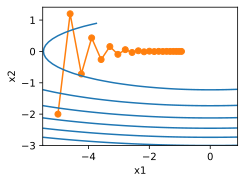

In [2]:
eta = 0.4
def f_2d(x1, x2):  # Objective
    return 0.1 * x1 ** 2 + 2 * x2 ** 2
def f_2d_grad(x1, x2):  # Gradient of the objective
    return (0.2 * x1, 4 * x2)
def gd_2d(x1, x2, s1, s2, f_grad):
    g1, g2 = f_grad(x1, x2)
    return (x1 - eta * g1, x2 - eta * g2, 0, 0)

d2l.show_trace_2d(f_2d, d2l.train_2d(gd_2d, f_grad=f_2d_grad))

The gradient in the $x_2$ direction is much larger and changes much faster
than in $x_1$, so one learning rate serves two masters. Keep it small and the
iterate does not diverge in $x_2$ — but crawls along $x_1$, as above. Raise
it, and progress along $x_1$ improves while $x_2$ starts to oscillate out of
control. Even the slight increase from $0.4$ to $0.6$ tips the balance:

epoch 20, x1: -0.387814, x2: -1673.365109


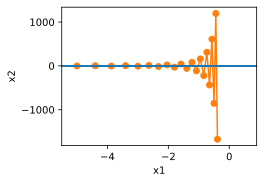

In [3]:
eta = 0.6
d2l.show_trace_2d(f_2d, d2l.train_2d(gd_2d, f_grad=f_2d_grad))

The information needed to do better is sitting in the history of the
trajectory. Along $x_1$ successive gradients agree — small, but all pointing
the same way. Along $x_2$ they alternate in sign, each step undoing the last.
An average over past gradients would amplify the first and cancel the second.

## The Momentum Method

### Leaky Averages

Minibatches (that section) average gradients across
*examples*. The idea here is to also average across *time*, with an average
that leaks: discount each past gradient by a factor of $\beta$ per step.
Concretely, replace the gradient in the update by a *velocity*
$\mathbf{v}_t$,

$$
\begin{aligned}
\mathbf{v}_t &\leftarrow \beta \mathbf{v}_{t-1} + \mathbf{g}_{t}, \\
\mathbf{x}_t &\leftarrow \mathbf{x}_{t-1} - \eta\, \mathbf{v}_t,
\end{aligned}
$$

where $\beta \in [0, 1)$, $\mathbf{g}_t$ is the gradient — full-batch,
single-example, or minibatch — evaluated at $\mathbf{x}_{t-1}$, and
$\mathbf{v}_0 = \mathbf{0}$. For $\beta = 0$ we recover plain gradient
descent. Unrolling the recursion shows what the velocity holds:

$$\mathbf{v}_t = \sum_{\tau = 0}^{t-1} \beta^{\tau} \mathbf{g}_{t-\tau},$$

an exponentially weighted sum of all past gradients. The name comes from the
physical picture: a heavy ball rolling down the objective integrates past
forces rather than reacting to the instantaneous slope, and $1 - \beta$
plays the role of friction. This is *heavy-ball momentum*, due to
@Polyak.1964; @Sutskever.Martens.Dahl.ea.2013 document how
much it matters for training deep networks, and the expository article by
@Goh.2017 develops everything in this section with interactive
animations.

### Back to the Valley

On the valley, the leaky average does exactly what the trajectory history
suggested: the persistent $x_1$ components accumulate while the alternating
$x_2$ components cancel. With the same learning rate $0.6$ that just
diverged, momentum $\beta = 0.5$ converges well:

epoch 20, x1: 0.007188, x2: 0.002553


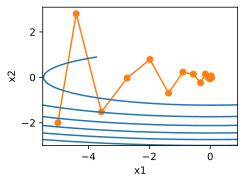

In [4]:
def momentum_2d(x1, x2, v1, v2, f_grad):
    g1, g2 = f_grad(x1, x2)
    v1, v2 = beta * v1 + g1, beta * v2 + g2
    return x1 - eta * v1, x2 - eta * v2, v1, v2

eta, beta = 0.6, 0.5
d2l.show_trace_2d(f_2d, d2l.train_2d(momentum_2d, f_grad=f_2d_grad))

Halving the momentum to $\beta = 0.25$ weakens the effect — the trajectory
barely converges — but even this beats plain gradient descent, which diverged
outright at this learning rate:

epoch 20, x1: -0.126340, x2: -0.186632


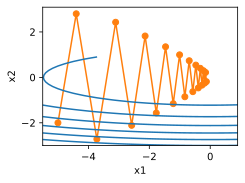

In [5]:
eta, beta = 0.6, 0.25
d2l.show_trace_2d(f_2d, d2l.train_2d(momentum_2d, f_grad=f_2d_grad))

Nothing in the equation requires the gradient to be exact. With
minibatch gradients the same leaky average additionally smooths the sampling
noise across steps — variance reduction beyond what the minibatch itself
buys, at no extra gradient evaluations. Momentum thus earns its keep twice:
against curvature, as above, and against noise.

### The Timescale of $\beta$

How much history does the velocity hold? The weights
$1, \beta, \beta^2, \ldots$ sum to $\frac{1}{1-\beta}$ in the limit, so a
useful reading is: **momentum $\beta$ averages over roughly the last
$\frac{1}{1-\beta}$ gradients**. $\beta = 0.9$ — the `momentum=0.9` you
have been passing to optimizers since that section — looks
back about $10$ steps; $\beta = 0.99$ about $100$. The plot shows how sharply
the weights decay for various $\beta$:

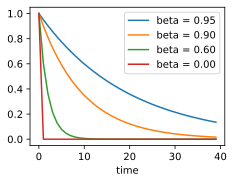

In [6]:
d2l.set_figsize()
x = d2l.numpy(d2l.arange(40))
for beta in [0.95, 0.9, 0.6, 0]:
    d2l.plt.plot(x, beta ** x, label=f'beta = {beta:.2f}')
d2l.plt.xlabel('time')
d2l.plt.legend();

The same sum says something about step length. When successive gradients
roughly agree, the velocity builds up to $\frac{1}{1-\beta}$ times a typical
gradient, so momentum takes steps of effective size
$\frac{\eta}{1-\beta}$ in persistent directions. This matters when tuning:
raising $\beta$ without lowering $\eta$ makes the updates larger, not just
smoother, and the two hyperparameters must move together — we will see this
in the experiments below.

### Acceleration and Damping

Momentum does more than stabilize; on ill-conditioned problems it is
provably *faster*. For a quadratic whose Hessian eigenvalues lie between
$\mu$ and $L$, the condition number $\kappa = L/\mu$ governs everything:
gradient descent needs on the order of $\kappa \log \frac{1}{\epsilon}$
iterations to reach precision $\epsilon$, while heavy-ball momentum with
optimally chosen $\eta$ and $\beta$ needs only on the order of
$\sqrt{\kappa} \log \frac{1}{\epsilon}$, achieved at

$$\beta^\star = \left(\frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}\right)^{\!2}.$$

For $\kappa = 100$ that is a $10\times$ saving with $\beta^\star \approx
0.67$; for $\kappa = 10^4$, a $100\times$ saving with $\beta^\star \approx
0.96$. Note the trend: the harder the problem, the closer $\beta^\star$
pushes toward $1$ — in the timescale reading, hard problems reward a memory
of roughly $\sqrt{\kappa}$ steps.

The right mental model for tuning $\beta$ is a damped oscillator. In each
eigendirection of the Hessian, the equation is a second-order
recurrence — a mass on a spring with friction $1 - \beta$. Too little
momentum and the system is *over-damped*: it creeps down the valley like
gradient descent. Too much and it is *under-damped*: the iterate overshoots
and rings around the minimum. The fastest setting, $\beta^\star$, sits at
critical damping between the two. Our valley has $\kappa = 20$, giving
$\beta^\star \approx 0.4$ — and in hindsight, the tuning that sailed down
the valley earlier, $\eta = 0.6$ with $\beta = 0.5$, sits close to the
optimum. Push $\beta$ too far and momentum turns against us. Here is
$\beta = 0.8$, well past the fastest-converging $\beta^\star$, at a
learning rate where plain gradient descent would be perfectly stable:

epoch 20, x1: 0.195696, x2: -0.249649


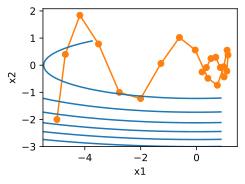

In [7]:
eta, beta = 0.3, 0.8
d2l.show_trace_2d(f_2d, d2l.train_2d(momentum_2d, f_grad=f_2d_grad))

![Convergence rate per step of heavy-ball momentum on a single quadratic mode, as a function of the momentum $\beta$. Below the critical value $\beta^{*}$ the iteration is over-damped and slow; at $\beta^{*}$ it is fastest; beyond it the rate degrades gently as $\sqrt{\beta}$. Worse conditioning (smaller $\eta\lambda$, dashed) pushes $\beta^{*}$ toward one — the reason large momentum values are the common default.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-opt-critical-damping.svg)

The trajectory now sails along the valley floor but orbits the minimum
before settling — momentum's own oscillation, distinct from the
learning-rate divergence we saw earlier. the figure
summarizes the tradeoff on a single quadratic mode: the per-step
convergence rate falls as $\beta$ grows, is best at a critical value
$\beta^{*}$, and degrades gently past it. The eigenmode analysis behind this
picture, the $\sqrt{\kappa}$ theorem and its matching lower bound, and the
proofs are developed in that section; one
caveat worth carrying away from there is that the heavy-ball $\sqrt{\kappa}$
rate is a statement about quadratics, and its practical standing on general
objectives rests on the local quadratic picture plus a long empirical record
[@Sutskever.Martens.Dahl.ea.2013].

## Implementation

### From Scratch

Compared with plain minibatch SGD, momentum needs to maintain one auxiliary
buffer per parameter — the velocity, with the same shape as the parameter.
In the harness of that section this is exactly what the
`states` argument is for.

In [8]:
def init_momentum_states(feature_dim):
    v_w = d2l.zeros((feature_dim, 1))
    v_b = d2l.zeros(1)
    return (v_w, v_b)

In [9]:
def sgd_momentum(params, states, hyperparams):
    for p, v in zip(params, states):
        with torch.no_grad():
            v[:] = hyperparams['momentum'] * v + p.grad
            p[:] -= hyperparams['lr'] * v
        p.grad.zero_()

On the airfoil regression problem, a moderate $\beta = 0.5$ with learning
rate $0.02$ trains without drama:

loss: 0.246, 0.131 sec/epoch


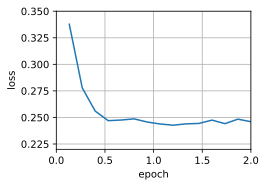

In [10]:
def train_momentum(lr, momentum, num_epochs=2):
    d2l.train_ch11(sgd_momentum, init_momentum_states(feature_dim),
                   {'lr': lr, 'momentum': momentum}, data_iter,
                   feature_dim, num_epochs)

data_iter, feature_dim = d2l.get_data_ch11(batch_size=10)
train_momentum(0.02, 0.5)

Raising the momentum to $\beta = 0.9$ extends the average to roughly
$\frac{1}{1-0.9} = 10$ past gradients — and, by the effective-step reading
above, quintuples the effective step $\frac{\eta}{1-\beta}$ if we leave
$\eta$ alone. We halve the learning rate to $0.01$ to rein it in:

loss: 0.254, 0.088 sec/epoch


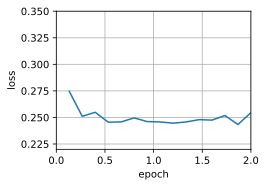

In [11]:
train_momentum(0.01, 0.9)

Halving it again to $0.005$ brings the effective step to $0.05$ — the range
of the first experiment — and the loss curve settles accordingly:

loss: 0.245, 0.080 sec/epoch


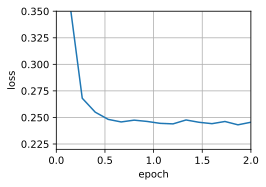

In [12]:
train_momentum(0.005, 0.9)

### Concise Implementation

Momentum is built into every framework's SGD optimizer as a single argument.
Matching the hyperparameters reproduces the trajectory.

loss: 0.246, 0.082 sec/epoch


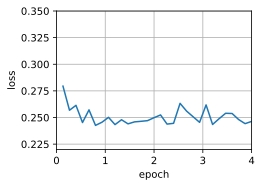

In [13]:
trainer = torch.optim.SGD
d2l.train_concise_ch11(trainer, {'lr': 0.005, 'momentum': 0.9}, data_iter)

## Nesterov Momentum

Heavy ball has one characteristic failure, and we have already seen it: with
$\beta$ past the critical value, the accumulated velocity overshoots and the
iterate rings around the minimum. @Nesterov.1983 proposed a fix of
almost comic economy — look before you leap. Evaluate the gradient not at
the current point but at the point the velocity is about to carry you to:

$$
\begin{aligned}
\mathbf{v}_t &\leftarrow \beta \mathbf{v}_{t-1} + \nabla f(\mathbf{x}_{t-1} - \eta \beta\, \mathbf{v}_{t-1}), \\
\mathbf{x}_t &\leftarrow \mathbf{x}_{t-1} - \eta\, \mathbf{v}_t.
\end{aligned}
$$

If the momentum step is about to overshoot, the gradient at the look-ahead
point already points back, correcting the velocity *before* the mistake
rather than one step after. In code it is a two-line change to the momentum
update — the gradient is taken at the shifted point:

epoch 20, x1: 0.217791, x2: -0.000070


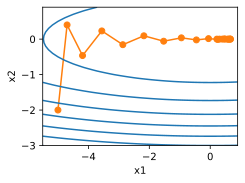

In [14]:
def nesterov_2d(x1, x2, v1, v2, f_grad):
    g1, g2 = f_grad(x1 - eta * beta * v1,  # Gradient at the look-ahead
                    x2 - eta * beta * v2)  # point, not at (x1, x2)
    v1, v2 = beta * v1 + g1, beta * v2 + g2
    return x1 - eta * v1, x2 - eta * v2, v1, v2

eta, beta = 0.3, 0.8
d2l.show_trace_2d(f_2d, d2l.train_2d(nesterov_2d, f_grad=f_2d_grad))

Same learning rate, same $\beta = 0.8$ that made heavy ball ring — and the
oscillation is gone: the look-ahead acts as built-in damping. Beyond the
picture, Nesterov's method carries guarantees that heavy ball lacks. On
smooth convex functions it converges as $\mathcal{O}(1/k^2)$ against
gradient descent's $\mathcal{O}(1/k)$, which is optimal for any method built
from gradients; on strongly convex functions it achieves the
$\sqrt{\kappa}$ rate with a proof that is not confined to quadratics
[@Nesterov.2018]. Statements, proofs, and the matching lower bound are
in that section.

In frameworks, Nesterov momentum is one flag. Both PyTorch and Optax
implement an equivalent rewrite of the equation that evaluates the
gradient at the current iterate (the exercises ask you to verify the
equivalence), so no extra gradient evaluation is needed:

loss: 0.244, 0.080 sec/epoch


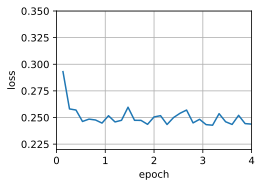

In [15]:
d2l.train_concise_ch11(
    torch.optim.SGD,
    {'lr': 0.005, 'momentum': 0.9, 'nesterov': True}, data_iter)

On this small, noisy problem the curve is essentially indistinguishable from
plain momentum, as is typical at small batch: the look-ahead correction is
dwarfed by sampling noise.
Nesterov momentum earns its difference where curvature dominates noise —
full-batch or large-batch training, and $\beta$ pushed close to $1$. Since
it costs nothing extra, it is often simply switched on.

## Summary

Momentum replaces the gradient with a leaky average over past gradients —
one buffer, one hyperparameter $\beta$. On ill-conditioned problems it cures
the zigzag: persistent gradient components accumulate up to
$\frac{1}{1-\beta}$-fold while oscillating ones cancel, and with optimal
tuning the iteration count improves from order $\kappa$ to order
$\sqrt{\kappa}$. The parameter $\beta$ reads as a timescale — an average
over roughly $\frac{1}{1-\beta}$ recent gradients — and as a damping knob,
with too large a value producing ringing rather than progress. Nesterov's
look-ahead variant damps that ringing and carries convergence guarantees
beyond quadratics, at no extra cost per step. With stochastic gradients the
same leaky average also smooths sampling noise, which is why some form of
momentum appears in essentially every optimizer in the rest of this chapter.

## Exercises

1. Use other combinations of momentum hyperparameters and learning rates and observe and analyze the different experimental results.
1. Try out gradient descent and momentum for a quadratic problem where you have multiple eigenvalues, i.e., $f(x) = \frac{1}{2} \sum_i \lambda_i x_i^2$, e.g., $\lambda_i = 2^{-i}$. Plot how the values of $x$ decrease for the initialization $x_i = 1$.
1. PyTorch's `nesterov=True` performs $\mathbf{v}_t = \beta \mathbf{v}_{t-1} + \mathbf{g}_t$ followed by $\mathbf{x}_t = \mathbf{x}_{t-1} - \eta\,(\mathbf{g}_t + \beta \mathbf{v}_t)$, with the gradient taken at $\mathbf{x}_{t-1}$. Show by a change of variables that this generates the same iterates as the equation. What point do the framework's parameters correspond to?
1. For $f(x) = \frac{\lambda}{2} x^2$, sweep $\beta$ over $[0, 1)$ at fixed $\eta$ and measure the number of iterations until $|x_t| \leq 10^{-6} |x_0|$. Where is the minimum, and how does it compare to $\beta^\star$?
1. What changes when we use momentum with minibatch stochastic gradient descent? What happens as the batch size shrinks? Experiment with the parameters.

[Discussions](https://d2l.discourse.group/t/1070)